## Load the data

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

import sys; sys.path.append('..')

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

rdir  = '../../results/black-box/'
figdir = f'../figs/black-box/'
datadir = '../../datasets/blackbox/' # Set to path to datasets

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')


In [2]:
df_populations = pd.read_feather(rdir+'populations.feather')
df_results = pd.read_feather(rdir+'results.feather')

print(df_populations.shape)
print(df_results.shape)

df_results = pd.merge(
    left=df_populations, 
    right=df_results,
    how='left',
    left_on=['dataset', 'algorithm', 'random_state'],
    right_on=['dataset', 'algorithm', 'random_state'],
    suffixes=("_from_pop", None)
)

print(df_results.shape)
print(df_results.columns)

(41334, 14)
(1383, 22)
(41334, 33)
Index(['dataset', 'algorithm', 'random_state', 'index', 'model_size_from_pop',
       'mse_train', 'mae_train', 'r2_train', 'mse_test_from_pop',
       'mae_test_from_pop', 'r2_test_from_pop', 'symbolic_alg_from_pop',
       'pre_trained_from_pop', 'gp_alg_from_pop', 'training time (s)',
       'symbolic_model', 'mse_test', 'mae_test', 'r2_test', 'model_size',
       'params_str', 'training time (hr)', 'symbolic_alg', 'pre_trained',
       'gp_alg', 'r2_zero_test', 'friedman_dataset', 'algorithm_count',
       'mse_test_rank_per_trial', 'mae_test_rank_per_trial',
       'r2_test_rank_per_trial', 'model_size_rank_per_trial',
       'r2_zero_test_rank_per_trial'],
      dtype='object')


/tmp/ipykernel_56309/1250859017.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_agg = df_results.groupby(['dataset', 'algorithm', 'random_state'])\


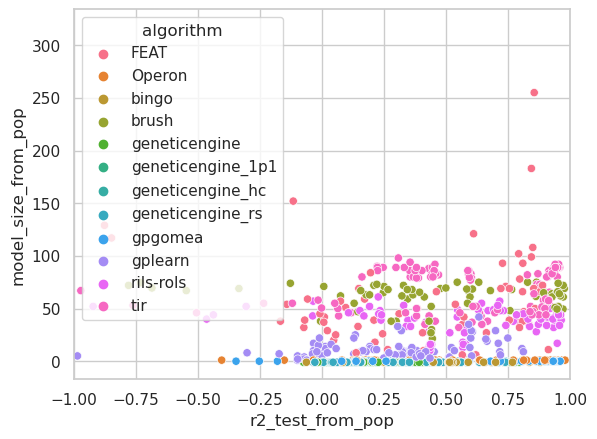

In [3]:
# Aggregating statistics from the populations
df_results = df_results.dropna()

df_agg = df_results.groupby(['dataset', 'algorithm', 'random_state'])\
          .median().reset_index()

sns.scatterplot(data=df_agg, y='model_size_from_pop', x='r2_test_from_pop', hue='algorithm')
plt.xlim(-1, 1)
plt.show()

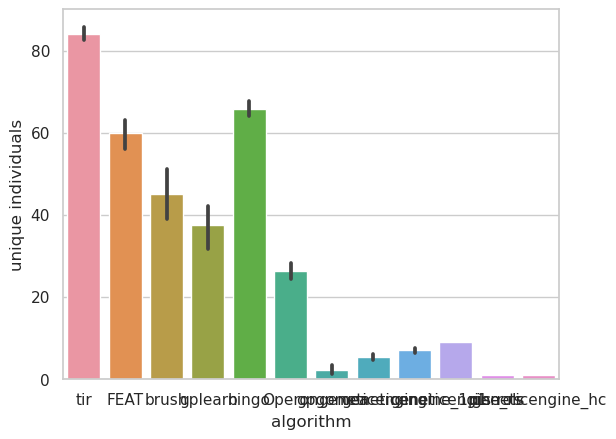

In [4]:
# Aggregating statistics from the populations
df_agg = df_results.set_index(['dataset', 'algorithm', 'random_state'])\
          [['model_size_from_pop', 'r2_test_from_pop']].drop_duplicates()\
          .reset_index()[['dataset', 'algorithm', 'random_state']]\
          .value_counts(ascending=False).reset_index()

df_agg.columns = ['dataset', 'algorithm', 'random_state', 'unique individuals']

# display(df_agg)

sns.barplot(data=df_agg, x='algorithm', y='unique individuals')
plt.show()

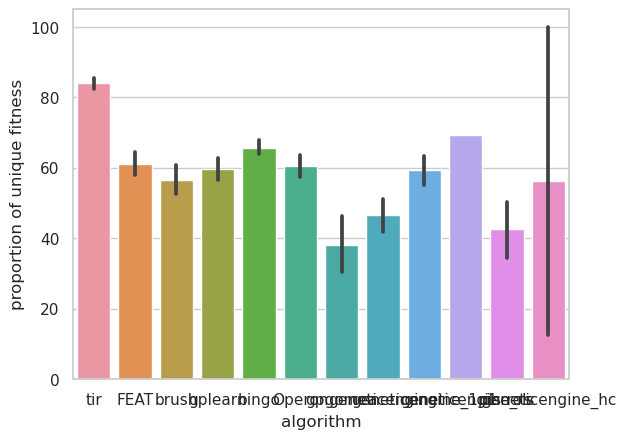

In [5]:
# Aggregating statistics from the populations
df_agg = df_results.set_index(['dataset', 'algorithm', 'random_state'])\
          [['model_size_from_pop', 'r2_test_from_pop']].drop_duplicates()\
          .reset_index()[['dataset', 'algorithm', 'random_state']]\
          .value_counts(ascending=False).reset_index()

df_agg.columns = ['dataset', 'algorithm', 'random_state', 'unique individuals']

# Calculate the proportion
df_tot = df_results[['dataset', 'algorithm', 'random_state']]\
          .value_counts(ascending=False).reset_index()

df_tot.columns = ['dataset', 'algorithm', 'random_state', 'tot individuals']

df_agg['proportion of unique fitness'] = \
    (df_agg['unique individuals'] / df_tot['tot individuals']) * 100

sns.barplot(data=df_agg, x='algorithm', y='proportion of unique fitness')
plt.show()


/home/ch246537/.conda/envs/srbench/lib/python3.9/site-packages/pymoo/vendor/hv.py:79: RuntimeWarning: invalid value encountered in double_scalars
  hvol += h * (q.cargo[1] - pCargo[1])
/home/ch246537/.conda/envs/srbench/lib/python3.9/site-packages/pymoo/vendor/hv.py:79: RuntimeWarning: invalid value encountered in double_scalars
  hvol += h * (q.cargo[1] - pCargo[1])
/home/ch246537/.conda/envs/srbench/lib/python3.9/site-packages/numpy/lib/function_base.py:3961: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


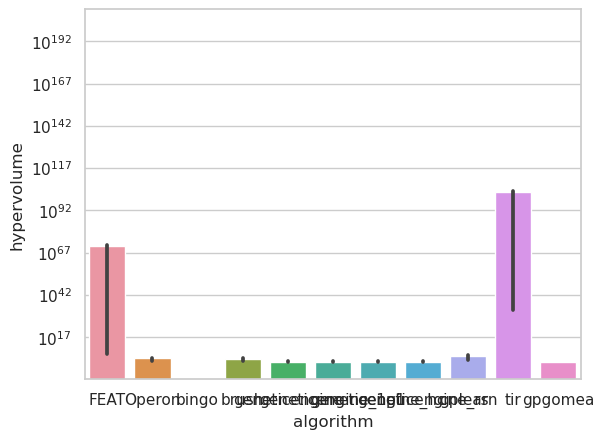

In [6]:
# !pip install pymoo
from pymoo.indicators.hv import HV

# Filter algorithms with single individual in pareto front --- hv does not work well
counts = df_results.groupby(['dataset', 'algorithm', 'random_state']).count()
invalid = counts[ counts['index']<=1 ].index

df_results_clean = df_results[
    ~df_results.set_index(['dataset', 'algorithm', 'random_state']).index.isin(invalid)
]

# max_model_size_from_pop = np.percentile(df_results_clean['model_size_from_pop'], 95)
max_model_size_from_pop = np.max(df_results_clean['model_size_from_pop'])

# Create the Hypervolume indicator object
hv = HV(ref_point=np.array([max_model_size_from_pop, 1.0]))

# Aggregating statistics from the populations.
# They should be both minimization --- the higher the hv the better.
df_agg = df_results_clean.groupby(['dataset', 'algorithm', 'random_state'])\
          .apply(lambda x: hv.do(x[['model_size_from_pop', 'r2_test_from_pop']].values*[-1.0, 1.0])
        ) \
        .reset_index()

df_agg.columns = ['dataset', 'algorithm', 'random_state', 'hypervolume']

# display(df_agg)

sns.barplot(data=df_agg, x='algorithm', y='hypervolume')
plt.yscale('log')
plt.show()